# nb01 — QC and Structure Inspection
COVID-19 CITE-seq dataset (E-MTAB-10026, `covid_portal_210320_with_raw.h5ad`). Exploration only — no filtering or transforms applied here. Annotation CSV dropped: everything it provided (`full_clustering`) is already in `adata.obs`.

## Environment setup (Colab or local)

In [19]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## Imports and config

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = BASE_PATH / 'data' / 'raw'
H5AD = DATA_DIR / 'covid_portal_210320_with_raw.h5ad'

RESULTS_DIR = BASE_PATH / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = DATA_DIR.parent / 'processed'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print('H5AD exists:', H5AD.exists())

## Load h5ad in backed mode
7.19 GB on disk — load backed so we can inspect structure without pulling the full matrix into memory.

In [ ]:
adata = sc.read_h5ad(H5AD, backed='r')

In [39]:
print(adata)
print()
print('Shape (n_cells x n_features):', adata.shape)

AnnData object with n_obs × n_vars = 647366 × 24929 backed at '/content/drive/MyDrive/covid_citeseq_project/data/raw/covid_portal_210320_with_raw.h5ad'
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id'
    var: 'feature_types'
    uns: 'hvg', 'leiden', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'raw'

Shape (n_cells x n_features): (647366, 24929)


### var — confirm GEX / ADT split (the critical checkpoint)

In [20]:
print('--- var columns ---')
print(adata.var.columns.tolist())
print()
print('--- feature_types value counts ---')
print(adata.var['feature_types'].value_counts())

--- var columns ---
['feature_types']

--- feature_types value counts ---
feature_types
Gene Expression     24737
Antibody Capture      192
Name: count, dtype: int64


In [21]:
gex_mask = adata.var['feature_types'] == 'Gene Expression'
adt_mask = adata.var['feature_types'] == 'Antibody Capture'

gex_names = adata.var_names[gex_mask]
adt_names = adata.var_names[adt_mask]

print(f'GEX features: {gex_mask.sum():,}')
print(f'ADT features: {adt_mask.sum():,}')
print()
print('Sample GEX names:', gex_names[:10].tolist())
print('Sample ADT names:', adt_names[:10].tolist())

GEX features: 24,737
ADT features: 192

Sample GEX names: ['MIR1302-2HG', 'AL627309.1', 'AL627309.3', 'AL627309.2', 'AL669831.2', 'FAM87B', 'LINC00115', 'FAM41C', 'AL645608.2', 'SAMD11']
Sample ADT names: ['AB_CD80', 'AB_CD86', 'AB_CD274', 'AB_PDCD1LG2', 'AB_ICOSLG', 'AB_ITGAM', 'AB_OX40L', 'AB_TNFSF9', 'AB_PVR', 'AB_NECTIN2']


### obsm, layers, uns

In [22]:
print('--- obsm keys ---')
print(list(adata.obsm.keys()))
print()
print('--- layers keys ---')
print(list(adata.layers.keys()))
print()
print('--- uns keys ---')
print(list(adata.uns.keys()))

--- obsm keys ---
['X_pca', 'X_pca_harmony', 'X_umap']

--- layers keys ---
['raw']

--- uns keys ---
['hvg', 'leiden', 'neighbors', 'pca', 'umap']


### obs — full column list and head

In [23]:
print('--- obs columns ---')
print(adata.obs.columns.tolist())
print()
display(adata.obs.head())

--- obs columns ---
['sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id']



,sample_id,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,full_clustering,initial_clustering,Resample,Collection_Day,...,Status,Smoker,Status_on_day_collection,Status_on_day_collection_summary,Days_from_onset,Site,time_after_LPS,Worst_Clinical_Status,Outcome,patient_id
covid_index,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGAAACCTA-MH9179824,MH9179824,1160,1160,2172.0,79.0,3.637201,CD8.TE,CD8,Initial,D0,...,Covid,Non-smoker,Ward_O2,Moderate,8,Ncl,nan,Moderate,Home,MH9179824
AAACCTGAGAGTAATC-MH9179824,MH9179824,1419,1419,3947.0,54.0,1.368128,CD4.IL22,CD4,Initial,D0,...,Covid,Non-smoker,Ward_O2,Moderate,8,Ncl,nan,Moderate,Home,MH9179824
AAACCTGAGAGTGAGA-MH9179824,MH9179824,1986,1986,5886.0,143.0,2.429494,CD8.Naive,CD4,Initial,D0,...,Covid,Non-smoker,Ward_O2,Moderate,8,Ncl,nan,Moderate,Home,MH9179824
AAACCTGAGGAATCGC-MH9179824,MH9179824,1508,1508,4271.0,106.0,2.481854,CD4.Naive,CD4,Initial,D0,...,Covid,Non-smoker,Ward_O2,Moderate,8,Ncl,nan,Moderate,Home,MH9179824
AAACCTGAGTGTTGAA-MH9179824,MH9179824,1109,1109,2279.0,76.0,3.334796,CD8.EM,CD4,Initial,D0,...,Covid,Non-smoker,Ward_O2,Moderate,8,Ncl,nan,Moderate,Home,MH9179824


### X — raw, normalized, or log-transformed?

In [24]:
X = adata.X
X_sample = X[:1000]
if sp.issparse(X_sample):
    X_sample = X_sample.toarray()
else:
    X_sample = np.asarray(X_sample)

print('X dtype:', X.dtype)
print('X min/max (first 1000 cells):', X_sample.min(), X_sample.max())
print('X mean:', X_sample.mean())
print('Any negative values:', (X_sample < 0).any())
print('Any non-integer values:', not np.allclose(X_sample, np.round(X_sample)))
print()
print('layers[\'raw\'] present:', 'raw' in adata.layers)

X dtype: float32
X min/max (first 1000 cells): -7.4413214 8.085753
X mean: 0.08629331
Any negative values: True
Any non-integer values: True

layers['raw'] present: True


In [25]:
raw_sample = adata.layers['raw'][:1000]
if sp.issparse(raw_sample):
    raw_sample = raw_sample.toarray()
else:
    raw_sample = np.asarray(raw_sample)

print('raw layer dtype:', adata.layers['raw'].dtype)
print('raw layer min/max (first 1000 cells):', raw_sample.min(), raw_sample.max())
print('raw layer all integers:', np.allclose(raw_sample, np.round(raw_sample)))

raw layer dtype: float32
raw layer min/max (first 1000 cells): 0.0 17490.0
raw layer all integers: True


## Cell-type annotation completeness

In [26]:
for col in ['full_clustering', 'initial_clustering']:
    n_missing = adata.obs[col].isna().sum()
    n_unique = adata.obs[col].nunique()
    print(f'--- {col} ---')
    print(f'Missing: {n_missing:,} / {adata.n_obs:,}')
    print(f'Unique labels: {n_unique}')
    print(adata.obs[col].value_counts().head(15))
    print()

--- full_clustering ---
Missing: 0 / 647,366
Unique labels: 51
full_clustering
NK_16hi           92848
CD4.Naive         63096
CD14_mono         62336
CD83_CD14_mono    58507
CD8.TE            53534
CD4.CM            49904
B_naive           44136
CD8.Naive         31175
CD8.EM            18917
CD4.IL22          18379
CD16_mono         16626
gdT               15942
Platelets         15847
CD4.Tfh           13608
MAIT              10992
Name: count, dtype: int64

--- initial_clustering ---
Missing: 0 / 647,366
Unique labels: 18
initial_clustering
CD4             146380
CD14            121283
CD8             101704
NK_16hi          95311
B_cell           66833
CD16             20403
Platelets        17712
Treg             13256
NK_56hi          11672
gdT              10634
Plasmablast       9915
Lymph_prolif      7068
DCs               6938
MAIT              6835
pDC               4778
Name: count, dtype: int64



## Severity / disease status structure
Checking `Status`, `Status_on_day_collection_summary`, and `Worst_Clinical_Status` — these look like different granularities of the same underlying severity info.

In [27]:
for col in ['Status', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Worst_Clinical_Status', 'Outcome']:
    print(f'--- {col} ---')
    print(adata.obs[col].value_counts(dropna=False))
    print()

--- Status ---
Status
Covid        527286
Healthy       97039
Non_covid     15157
LPS            7884
Name: count, dtype: int64

--- Status_on_day_collection ---
Status_on_day_collection
Ward_O2            195293
Ward_noO2          142947
Healthy             97039
ITU_intubated       80852
ITU_NIV             54168
ITU_O2              28090
Staff screening     26590
Ward_NIV            12660
LPS                  7884
Non_covid            1843
Name: count, dtype: int64

--- Status_on_day_collection_summary ---
Status_on_day_collection_summary
Moderate        198632
Mild            135936
Healthy          97039
Critical         80852
Severe           78265
Asymptomatic     33601
Non_covid        15157
LPS_90mins        3999
LPS_10hours       3885
Name: count, dtype: int64

--- Worst_Clinical_Status ---
Worst_Clinical_Status
Moderate        179012
Healthy          97039
Mild             93835
nan              74913
Critical         63854
Death            41836
Severe           40235
Asymp

## Cell counts per patient and per severity tier

In [28]:
print('Unique patients:', adata.obs['patient_id'].nunique())
print()
patient_counts = adata.obs['patient_id'].value_counts()
print(patient_counts.describe())

Unique patients: 130

count      130.000000
mean      4979.738462
std       3328.469042
min         65.000000
25%       2225.500000
50%       4274.000000
75%       7763.250000
max      14317.000000
Name: count, dtype: float64


In [29]:
# Cross-tab: patients x severity tier (using Status_on_day_collection_summary as the tier column —
# adjust if a different column turns out to be the right granularity)
severity_col = 'Status_on_day_collection_summary'

patient_severity = adata.obs.groupby('patient_id')[severity_col].agg(lambda x: x.mode().iat[0] if not x.mode().empty else np.nan)
tier_patient_counts = patient_severity.value_counts()
print(f'Patients per {severity_col} tier:')
print(tier_patient_counts)
print()

tier_cell_counts = adata.obs[severity_col].value_counts()
print(f'Cells per {severity_col} tier:')
print(tier_cell_counts)

Patients per Status_on_day_collection_summary tier:
Status_on_day_collection_summary
Moderate        30
Mild            23
Healthy         23
Critical        15
Severe          13
Asymptomatic     9
LPS_10hours      6
LPS_90mins       6
Non_covid        5
Name: count, dtype: int64

Cells per Status_on_day_collection_summary tier:
Status_on_day_collection_summary
Moderate        198632
Mild            135936
Healthy          97039
Critical         80852
Severe           78265
Asymptomatic     33601
Non_covid        15157
LPS_90mins        3999
LPS_10hours       3885
Name: count, dtype: int64


In [30]:
# Cells per patient within each tier — needed to judge whether 3-4 patients/tier is viable
cells_per_patient_tier = (
    adata.obs.groupby(['patient_id', severity_col]).size()
    .reset_index(name='n_cells')
    .sort_values([severity_col, 'n_cells'], ascending=[True, False])
)
display(cells_per_patient_tier)

,patient_id,Status_on_day_collection_summary,n_cells
999,MH9143425,Asymptomatic,7011
297,CV0171,Asymptomatic,5492
162,CV0068,Asymptomatic,4951
144,CV0059,Asymptomatic,3219
288,CV0164,Asymptomatic,3038
...,...,...,...
1124,newcastle21,Severe,0
1133,newcastle21v2,Severe,0
1151,newcastle59,Severe,0
1160,newcastle65,Severe,0


## Other covariates (batch, site, age, sex, smoker)

In [31]:
for col in ['Sex', 'Age_interval', 'Site', 'Smoker', 'Collection_Day', 'Days_from_onset', 'Resample']:
    print(f'--- {col} ---')
    print(adata.obs[col].value_counts(dropna=False))
    print()

--- Sex ---
Sex
Male      334516
Female    312850
Name: count, dtype: int64

--- Age_interval ---
Age_interval
(50, 59]    170662
(40, 49]    125633
(60, 69]     90511
(70, 79]     88388
(30, 39]     76448
(80, 89]     49786
(20, 29]     42837
(90, 99]      3101
Name: count, dtype: int64

--- Site ---
Site
Ncl          441809
Cambridge    130644
Sanger        74913
Name: count, dtype: int64

--- Smoker ---
Smoker
Non-smoker    473160
Not_known      92621
Smoker         36230
Healthy        29610
LPS             7884
Ex-smoker       7861
Name: count, dtype: int64

--- Collection_Day ---
Collection_Day
D0     594368
D28     22519
D13      8182
D7       7987
D9       7300
D12      7010
Name: count, dtype: int64

--- Days_from_onset ---
Days_from_onset
Healthy      99502
9            60652
6            51316
13           43762
8            41534
10           39707
7            30975
1            26893
11           26883
2            21331
5            20902
14           20314
15           

## QC distributions (already computed in obs — n_genes, total_counts, pct_counts_mt)

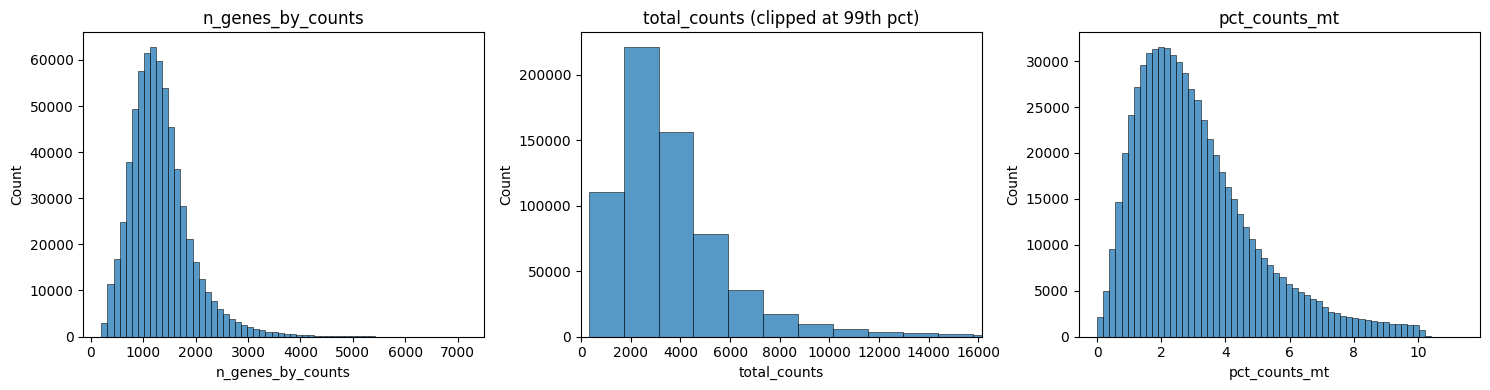

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(adata.obs['n_genes_by_counts'], bins=60, ax=axes[0])
axes[0].set_title('n_genes_by_counts')

sns.histplot(adata.obs['total_counts'], bins=60, ax=axes[1])
axes[1].set_xlim(0, adata.obs['total_counts'].quantile(0.99))
axes[1].set_title('total_counts (clipped at 99th pct)')

sns.histplot(adata.obs['pct_counts_mt'], bins=60, ax=axes[2])
axes[2].set_title('pct_counts_mt')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_qc_distributions.png', dpi=150)
plt.show()

In [33]:
print(adata.obs[['n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']].describe())

             n_genes  n_genes_by_counts   total_counts  total_counts_mt  \
count  647366.000000      647366.000000  647366.000000    647366.000000   
mean     1322.660492        1322.657728    3744.705078       110.582466   
std       578.615477         578.613351    3043.171143       118.464043   
min       200.000000         200.000000     305.000000         0.000000   
25%       934.000000         934.000000    2053.000000        45.000000   
50%      1241.000000        1241.000000    3067.000000        80.000000   
75%      1595.000000        1595.000000    4506.000000       136.000000   
max      7160.000000        7160.000000   84706.000000      3945.000000   

       pct_counts_mt  
count  647366.000000  
mean        3.088595  
std         1.896984  
min         0.000000  
25%         1.699942  
50%         2.693579  
75%         4.020101  
max        11.372549  


## Summary findings


- **ADT confirmed present:** Yes — split via `var['feature_types']` (`Gene Expression` vs `Antibody Capture`), same pattern as GSE194122. No separate protein file needed.
- **X representation:** TBD after running the X-inspection cells — check whether it's raw, normalized, or log-transformed, and confirm `layers['raw']` holds true raw counts.
- **Cell type annotation completeness:** TBD — check `full_clustering` vs `initial_clustering` for missing/unlabeled cells.
- **Severity tier structure:** TBD — decide whether to use `Status`, `Status_on_day_collection_summary`, or `Worst_Clinical_Status`, and whether any tiers are too small to use.
- **Subsample strategy:** Not yet decided — needs the patient-per-tier cell counts above to pick 3-4 patients per severity tier while keeping patient-level biology intact.

## Subsample selection
`Status_on_day_collection_summary` is the tier column (clean granularity, only Sanger-site gap is in `Worst_Clinical_Status`, which we're not using). `LPS_*` tiers are a separate experimental condition (LPS challenge), not COVID severity — excluded here.

In [34]:
severity_col = 'Status_on_day_collection_summary'
excluded_tiers = ['LPS_90mins', 'LPS_10hours']
N_PATIENTS_PER_TIER = 4

tier_counts = (
    adata.obs[~adata.obs[severity_col].isin(excluded_tiers)]
    .groupby(['patient_id', severity_col])
    .size()
    .reset_index(name='n_cells')
)
tier_counts = tier_counts[tier_counts['n_cells'] > 0]

selected = (
    tier_counts.sort_values('n_cells', ascending=False)
    .groupby(severity_col)
    .head(N_PATIENTS_PER_TIER)
    .sort_values([severity_col, 'n_cells'], ascending=[True, False])
)
display(selected)

,patient_id,Status_on_day_collection_summary,n_cells
999,MH9143425,Asymptomatic,7011
297,CV0171,Asymptomatic,5492
162,CV0068,Asymptomatic,4951
144,CV0059,Asymptomatic,3219
838,MH9143277,Critical,11710
91,AP12,Critical,8574
721,MH8919328,Critical,8182
802,MH9143273,Critical,7987
767,MH8919333,Healthy,12081
758,MH8919332,Healthy,8004


In [35]:
selected_patients = selected['patient_id'].tolist()
mask = adata.obs['patient_id'].isin(selected_patients).values

adata_sub = adata[mask].to_memory()
print(adata_sub.shape)
print(adata_sub.obs[severity_col].value_counts())

adata_sub.write_h5ad(CHECKPOINT_DIR / 'covid_subsampled.h5ad')

(228846, 24929)
Status_on_day_collection_summary
Moderate        49144
Mild            40278
Critical        36453
Severe          34581
Healthy         34201
Asymptomatic    20673
Non_covid       13516
Name: count, dtype: int64


## Batch-effect check
Two PCAs are stored (`X_pca`, `X_pca_harmony`) but only one `X_umap` — checking which PCA it was actually built on before trusting it as a post-harmony view.

In [36]:
print('--- pca params ---')
print(adata.uns.get('pca', {}).get('params', {}))
print()
print('--- neighbors params ---')
print(adata.uns.get('neighbors', {}).get('params', {}))

--- pca params ---
{'use_highly_variable': np.True_, 'zero_center': np.True_}

--- neighbors params ---
{'method': 'umap', 'metric': 'euclidean', 'n_neighbors': np.int64(10), 'n_pcs': np.int64(40), 'use_rep': 'X_pca_harmony'}


In [37]:
import numpy as np

N_PLOT = 60_000
rng = np.random.default_rng(0)
plot_idx = np.sort(rng.choice(adata.n_obs, size=min(N_PLOT, adata.n_obs), replace=False))

umap_coords = adata.obsm['X_umap'][plot_idx]
obs_plot = adata.obs.iloc[plot_idx]

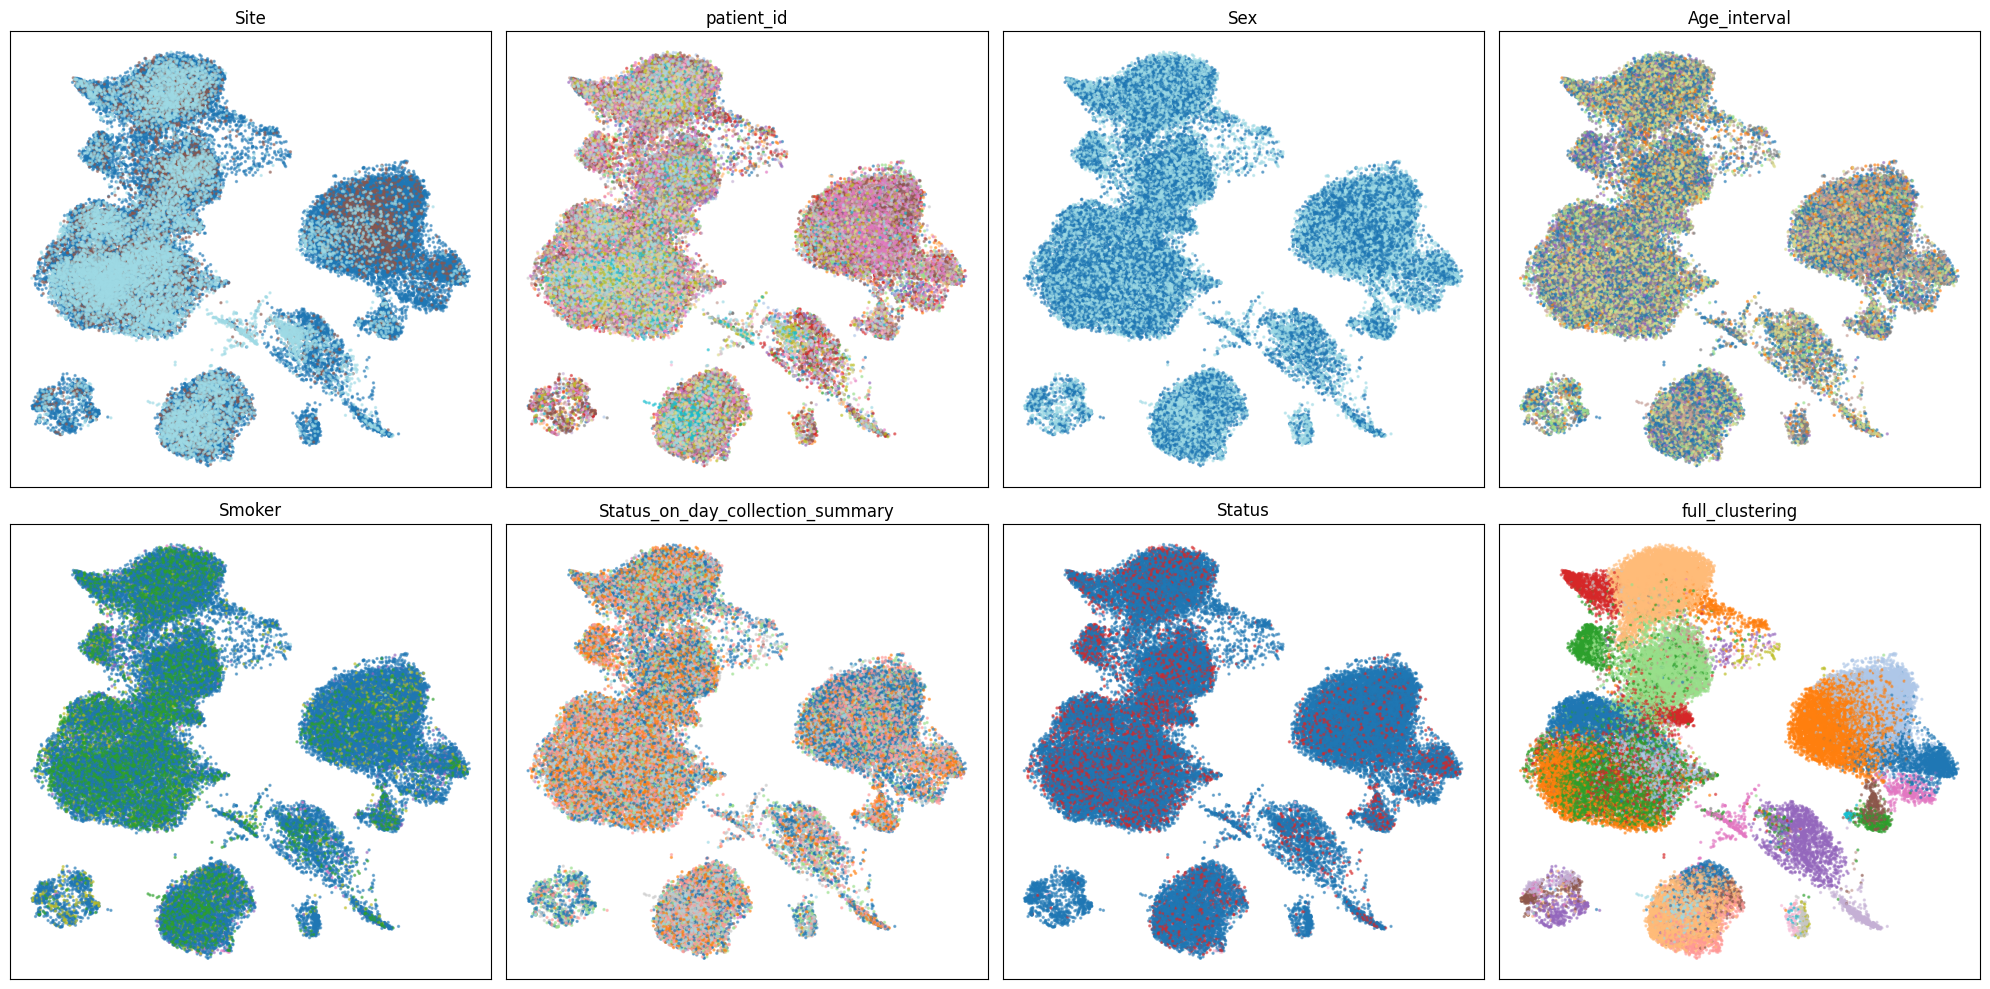

In [38]:
def plot_umap_by(ax, coords, values, title, categorical=True):
    """Scatter UMAP coords colored by a covariate; categorical uses tab20, else viridis."""
    if categorical:
        codes, _ = pd.factorize(values.astype(str))
        ax.scatter(coords[:, 0], coords[:, 1], c=codes, cmap='tab20', s=2, alpha=0.5)
    else:
        ax.scatter(coords[:, 0], coords[:, 1], c=values, cmap='viridis', s=2, alpha=0.5)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

covariates = ['Site', 'patient_id', 'Sex', 'Age_interval', 'Smoker',
              'Status_on_day_collection_summary', 'Status', 'full_clustering']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for col, ax in zip(covariates, axes.flat):
    plot_umap_by(ax, umap_coords, obs_plot[col], col)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_umap_batch_check.png', dpi=150)
plt.show()

`full_clustering` is included as a reference: if the other panels (especially `Site` and `patient_id`) show the same structure as cell type, that's residual batch effect. If they look mixed while cell type still shows clear islands, integration held.

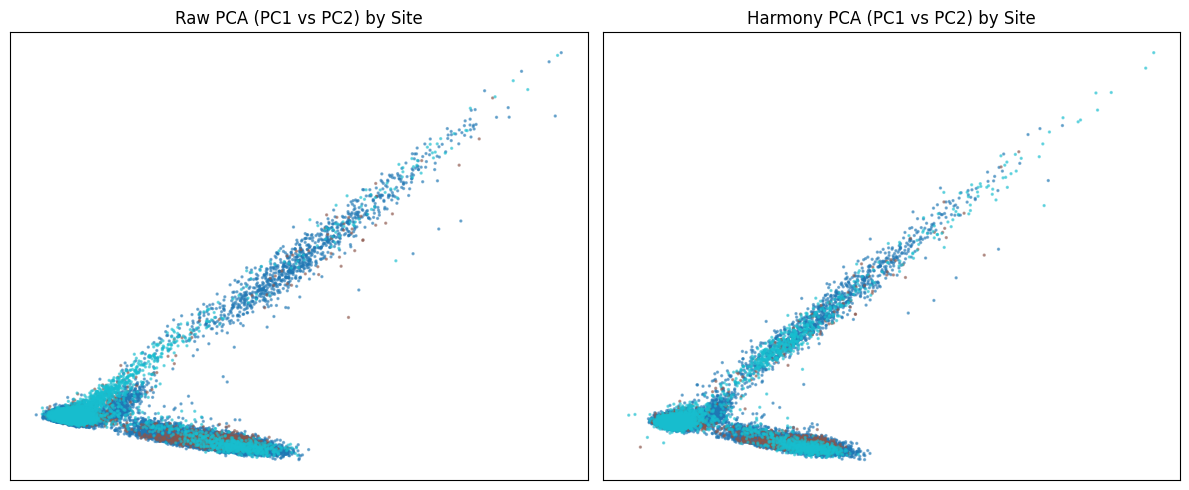

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pca_raw = adata.obsm['X_pca'][plot_idx]
pca_harmony = adata.obsm['X_pca_harmony'][plot_idx]
site_codes, _ = pd.factorize(obs_plot['Site'])

axes[0].scatter(pca_raw[:, 0], pca_raw[:, 1], c=site_codes, cmap='tab10', s=2, alpha=0.5)
axes[0].set_title('Raw PCA (PC1 vs PC2) by Site')
axes[1].scatter(pca_harmony[:, 0], pca_harmony[:, 1], c=site_codes, cmap='tab10', s=2, alpha=0.5)
axes[1].set_title('Harmony PCA (PC1 vs PC2) by Site')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_pca_harmony_comparison.png', dpi=150)
plt.show()

## Site coverage check 

In [41]:

severity_col = 'Status_on_day_collection_summary'
excluded_tiers = ['LPS_90mins', 'LPS_10hours']

site_tier_patients = (
    adata.obs[~adata.obs[severity_col].isin(excluded_tiers)]
    .groupby(['Site', severity_col])['patient_id']
    .nunique()
    .unstack(fill_value=0)
)
display(site_tier_patients)

Status_on_day_collection_summary,Asymptomatic,Critical,Healthy,LPS_10hours,LPS_90mins,Mild,Moderate,Non_covid,Severe
Site,,,,,,,,,
Cambridge,8,6,11,0,0,9,10,0,3
Ncl,1,7,12,0,0,11,17,5,7
Sanger,0,2,0,0,0,3,3,0,3


In [42]:
SELECTED_SITE = 'Cambridge'
N_PATIENTS_PER_TIER = 3

site_obs = adata.obs[(adata.obs['Site'] == SELECTED_SITE) & (~adata.obs[severity_col].isin(excluded_tiers))]

tier_counts = (
    site_obs.groupby(['patient_id', severity_col])
    .size()
    .reset_index(name='n_cells')
)
tier_counts = tier_counts[tier_counts['n_cells'] > 0]

selected = (
    tier_counts.sort_values('n_cells', ascending=False)
    .groupby(severity_col)
    .head(N_PATIENTS_PER_TIER)
    .sort_values([severity_col, 'n_cells'], ascending=[True, False])
)
display(selected)

,patient_id,Status_on_day_collection_summary,n_cells
297,CV0171,Asymptomatic,5492
162,CV0068,Asymptomatic,4951
144,CV0059,Asymptomatic,3219
406,CV0284,Critical,4259
397,CV0279,Critical,2720
334,CV0198,Critical,2348
434,CV0904,Healthy,6853
425,CV0902,Healthy,3884
488,CV0934,Healthy,3408
185,CV0074,Mild,5731


In [43]:
# --- Build and save subsampled checkpoint ---
selected_patients = selected['patient_id'].tolist()
mask = adata.obs['patient_id'].isin(selected_patients).values

adata_sub = adata[mask].to_memory()
print(adata_sub.shape)
print(adata_sub.obs[severity_col].value_counts())

(69681, 24929)
Status_on_day_collection_summary
Healthy         14145
Mild            13858
Asymptomatic    13662
Moderate        11525
Critical         9327
Severe           7164
Name: count, dtype: int64


In [44]:
adata_sub.write_h5ad(CHECKPOINT_DIR / 'covid_subsampled.h5ad')